# Mecanismos de atención eficiente

Hasta el momento, hemos trabajado con problemas relativamente simples. Las arquitecturas vistas hasta el momento perfectamente podrían resolver problemas de 20, 50 o hasta 100 ciudades. Pero, ¿qué pasa cuando incrementamos el número de ciudades?

Los modelos Transformer presentan una limitación importante en cuanto a la escalabilidad a diferentes tamaños del problema. En particular, la complejidad temporal del mecanismo de atención varía en función de la **longitud** de las secuencias atendidas. Si tenemos dos secuencias, una de longitud $N$ y otra de longitud $M$, la complejidad temporal de la atención crece proporcionalmente a $N \cdot M$. En el caso de *self-attention*, donde los elementos se una misma secuencia se atienden entre sí, este factor se simplifica a $N^2$.

En el caso del TSP, el tamaño del problema está dado por el **número de ciudades**. Si utilizamos *self-attention* entre ciudades dentro de nuestra arquitectura (sin importar si son todas las ciudades o solo algunas) el tiempo crecerá de manera **cuadrática** respecto al número de ciudades, siendo inviable para resolver instancias demasiado grandes.

Sin embargo, es necesario hacer una distinción:

> La arquitectura *glimpse* clásica utiliza *self-attention* dentro del encoder, y el encoder es procesado una única vez para formar la representación inicial del problema. Debido a que solo se ejecuta una sola vez, normalmente es aceptable que el costo computacional sea un poco mayor en esta parte de la arquitectura.

A pesar de esto, también existen variantes que utilizan *self-attention* dentro del decoder, por ejemplo para formar la representación global del tour a partir de las ciudades visitadas. Como el decoder es llamado en cada paso de construcción del tour, los efectos del costo computacional de la atención empiezan a notarse considablemente conforme crece el número de ciudades visitadas.

Existen técnicas para reducir el costo computacional de la atención tradicional. Para visualizar los efectos de estas técnicas, las aplicaremos sobre la arquitectura de **Circular Positional Encoding** (CPE), la cual precisamente utiliza *self-attention* dentro del decoder para la representación del tour actual.

## Preparación del entorno

Antes que nada, prepararemos los datos para el entrenamiento de los modelos.

In [1]:
from instances.instances import generate_instances

instances = generate_instances(filename="TSP50.pkl", instance_count=1000, cities=50, seed=42)

from data.generation import generate_train_data
from data.adapters.input.default import DefaultInputAdapter
from data.adapters.output.default import DefaultOutputAdapter

input_config = (DefaultInputAdapter, 50)
output_config = (DefaultOutputAdapter, 50)

generate_train_data(
    instance_file="TSP50.pkl", 
    data_filename="train_data.h5", 
    input_adapter_config=input_config, 
    output_adapter_config=output_config,
    size=5000
)

from data.preprocessing import load_dataset, split_dataset

# Split 80/20
train_file, val_file = split_dataset("train_data.h5", 4000)

train_dataset = load_dataset(train_file)
val_dataset = load_dataset(val_file)

Datos guardados en: /home/oscar/Escritorio/TSP-Framework/data/train_data.h5 (Tamaño: 5000)
Cargando dataset original: /home/oscar/Escritorio/TSP-Framework/data/train_data.h5
Guardando Train puro (4000 muestras) en: train_data_train.h5
Guardando Val puro (1000 muestras) en: train_data_val.h5
Dataset train_data_train.h5 cargado con 4000 muestras.
Dataset train_data_val.h5 cargado con 1000 muestras.


## Linear Unified Nested Attention (LUNA)

Esta técnica divide la capa tradicional de self-attention en dos bloques secuenciales de cross-attention. Gracias a esto, la complejidad computacional se reduce para escalar en función de $O(N \cdot P)$, donde $N$ es el tamaño de la secuencia y $P$ es una longitud constante.

El mecanismo introduce una **secuencia auxiliar** (de longitud $P$) que actúa como un **depósito** de memoria central. En el primer bloque de cross-attention, esta secuencia extrae y condensa la información más relevante de la secuencia principal (de tamaño $N$). Posteriormente, en el segundo bloque, la secuencia principal atiende "de vuelta" a este depósito resumido, logrando su contextualización global de forma mucho más eficiente.

<img src="../resources/luna.png" width="600" alt="Técnica de Linear Unified Nested Attention">

Para visualizar su funcionamiento, imaginemos un caso donde el modelo necesita saber qué tan lejos está la ciudad actual de la ciudad de origen (algo útil para no alejarse demasiado si ya estamos llegando al final del recorrido). En el primer bloque, la secuencia auxiliar actúa como query para ubicar y memorizar la posición exacta del origen. En el segundo bloque, cada ciudad (incluida la actual) consulta este depósito condensado para calcular instantáneamente su propia distancia relativa al punto de partida.

Este es, por supuesto, un ejemplo muy simplificado. En la práctica, el modelo despliega múltiples cabezas y capas dentro de un gran bloque de **Multi-Head Attention**, lo que le permite capturar simultáneamente cientos de relaciones espaciales altamente complejas. Como es habitual en *Deep Learning*, estas redes operan en gran medida como cajas negras: las representaciones matemáticas exactas que el modelo decide aprender suelen escapar a nuestra interpretabilidad humana directa, aunque los resultados evidencian que logran capturar la esencia geométrica del problema.

Como es habitual, vamos a implementar y entrenar un modelo que hace uso de esta técnica, para posteriormente validar sus resultados.

In [3]:
from models.luna import TSPTransformer

# Parámetros del modelo
input_dim = 2
embed_dim = 64
num_heads = 4
num_encoder_layers = 2
num_glimpses = 2
dropout = 0.1
p_len = 16 # Secuencia auxliar de longitud 16

# Crear modelo
luna_model = TSPTransformer(
    input_dim=input_dim,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_encoder_layers=num_encoder_layers,
    num_glimpses=num_glimpses,
    dropout_rate=dropout,
    p_len=p_len
)

from training.sl import sl_train, LRConfig
from training.metrics import CrossEntropyLoss, Accuracy

luna_model = sl_train(
    model=luna_model,
    epochs=10,
    train_set=train_dataset,
    val_set=val_dataset,
    batch_size=64,
    lr_config=LRConfig(value=1e-4),
    loss_fn=CrossEntropyLoss(),
    metrics=[Accuracy()],
    metrics_filename="luna_metrics.txt"
)

** Usando dispositivo: cpu

Epoch 1/10
    Train CrossEntropy: 2.2588 | Val CrossEntropy: 1.4276
    Accuracy: 64.60%
Epoch 2/10
    Train CrossEntropy: 1.3916 | Val CrossEntropy: 1.0693
    Accuracy: 77.40%
Epoch 3/10
    Train CrossEntropy: 1.0680 | Val CrossEntropy: 0.8762
    Accuracy: 79.90%
Epoch 4/10
    Train CrossEntropy: 0.9548 | Val CrossEntropy: 0.8036
    Accuracy: 80.40%
Epoch 5/10
    Train CrossEntropy: 0.8772 | Val CrossEntropy: 0.7501
    Accuracy: 80.60%
Epoch 6/10
    Train CrossEntropy: 0.8273 | Val CrossEntropy: 0.7031
    Accuracy: 81.40%
Epoch 7/10
    Train CrossEntropy: 0.7848 | Val CrossEntropy: 0.6875
    Accuracy: 81.30%
Epoch 8/10
    Train CrossEntropy: 0.7661 | Val CrossEntropy: 0.6636
    Accuracy: 82.00%
Epoch 9/10
    Train CrossEntropy: 0.7455 | Val CrossEntropy: 0.6479
    Accuracy: 81.30%
Epoch 10/10
    Train CrossEntropy: 0.7260 | Val CrossEntropy: 0.6379
    Accuracy: 81.80%

** Historial de entrenamiento guardado en: /home/oscar/Escritorio/TSP-

# Induced Set Attention Blocks (ISAB)

ISAB sigue la misma idea fundamental que LUNA: utilizar una secuencia auxiliar de longitud $P$ (un concepto conocido formalmente en la literatura como conjunto de **puntos inductores**) para condensar la información relevante y, posteriormente, retroalimentar la secuencia principal de longitud $N$ para su contextualización.

La diferencia se hace evidente al momento de apilar múltiples capas de atención. En LUNA, la secuencia auxiliar perdura capa tras capa, acumulando memoria en paralelo a la secuencia principal. En ISAB, por el contrario, cada capa inicializa y construye una secuencia auxiliar completamente **independiente**, la cual simplemente se desecha una vez finalizado el bloque.

¿Representa esto una ventaja o una desventaja? En realidad, ninguna; son simplemente dos enfoques distintos. LUNA emplea una única secuencia auxiliar dinámica que evoluciona a la par de la secuencia principal. ISAB, en cambio, opta por la flexibilidad, permitiendo que cada capa se especialice en generar un nuevo depósito temporal que capture únicamente la información más importante requerida en ese nivel de profundidad.

In [2]:
from models.isab import TSPTransformer

# Parámetros del modelo
input_dim = 2
embed_dim = 64
num_heads = 4
num_encoder_layers = 2
num_glimpses = 2
dropout = 0.1
p_inds = 16 # 16 puntos inductores 

# Crear modelo
isab_model = TSPTransformer(
    input_dim=input_dim,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_encoder_layers=num_encoder_layers,
    num_glimpses=num_glimpses,
    dropout_rate=dropout,
    p_inds=p_inds
)

from training.sl import sl_train, LRConfig
from training.metrics import CrossEntropyLoss, Accuracy

isab_model = sl_train(
    model=isab_model,
    epochs=10,
    train_set=train_dataset,
    val_set=val_dataset,
    batch_size=64,
    lr_config=LRConfig(value=1e-4),
    loss_fn=CrossEntropyLoss(),
    metrics=[Accuracy()],
    metrics_filename="luna_metrics.txt"
)

** Usando dispositivo: cpu

Epoch 1/10
    Train CrossEntropy: 2.0837 | Val CrossEntropy: 1.4034
    Accuracy: 66.50%
Epoch 2/10
    Train CrossEntropy: 1.3302 | Val CrossEntropy: 1.0079
    Accuracy: 78.80%
Epoch 3/10
    Train CrossEntropy: 1.0386 | Val CrossEntropy: 0.8792
    Accuracy: 79.30%
Epoch 4/10
    Train CrossEntropy: 0.9355 | Val CrossEntropy: 0.7973
    Accuracy: 80.50%
Epoch 5/10
    Train CrossEntropy: 0.8719 | Val CrossEntropy: 0.7510
    Accuracy: 80.60%
Epoch 6/10
    Train CrossEntropy: 0.8327 | Val CrossEntropy: 0.7148
    Accuracy: 81.50%
Epoch 7/10
    Train CrossEntropy: 0.8019 | Val CrossEntropy: 0.6960
    Accuracy: 81.90%
Epoch 8/10
    Train CrossEntropy: 0.7668 | Val CrossEntropy: 0.6789
    Accuracy: 81.40%
Epoch 9/10
    Train CrossEntropy: 0.7473 | Val CrossEntropy: 0.6561
    Accuracy: 81.20%
Epoch 10/10
    Train CrossEntropy: 0.7275 | Val CrossEntropy: 0.6491
    Accuracy: 82.90%

** Historial de entrenamiento guardado en: /home/oscar/Escritorio/TSP-

# Validación

Para iniciar la fase de validación, evaluaremos el desempeño empírico de las arquitecturas LUNA e ISAB en términos de costo promedio y brecha de optimalidad (*gap*). Utilizaremos la función `evaluate` para procesar en paralelo un conjunto de prueba estándar de 50 ciudades, guardando los resultados iterativamente para contrastar las rutas generadas contra las soluciones casi óptimas de OR-Tools.

In [54]:
from solvers.eval import evaluate
from data.adapters.input.default import DefaultInputAdapter

# Configuración compartida
input_config = (DefaultInputAdapter, 50)
instance_file = "benchmarks/B50.pkl"

# Agrupamos los modelos en un diccionario para evaluar secuencialmente
models_to_evaluate = {
    "LUNA": luna_model,
    "ISAB": isab_model
}

# Diccionario para almacenar las soluciones sin sobrescribirlas
evaluation_results = {}

for name, model in models_to_evaluate.items():
    print(f"\n{'='*50}")
    print(f"Evaluando: {name}")
    print(f"{'='*50}")
    
    model_sols, ort_sols = evaluate(
        model=model,
        instance_file=instance_file,
        input_adapter_config=input_config,
        num_workers=None  # Utiliza todos los núcleos de CPU disponibles
    )
    
    # Guardamos los resultados por si se necesitan analizar o graficar posteriormente
    evaluation_results[name] = {
        "model_sols": model_sols,
        "ort_sols": ort_sols
    }


Evaluando: LUNA
Iniciando evaluación conjunta de 100 instancias con 12 workers...

RESULTADOS DE LA VALIDACIÓN
Costo promedio Modelo:   6.49
Costo promedio OR-Tools: 5.82
Gap de optimalidad:      11.48% ± 5.65%


Evaluando: ISAB
Iniciando evaluación conjunta de 100 instancias con 12 workers...

RESULTADOS DE LA VALIDACIÓN
Costo promedio Modelo:   6.49
Costo promedio OR-Tools: 5.82
Gap de optimalidad:      11.39% ± 6.15%



El verdadero beneficio de los mecanismos de atención lineal (o de puntos inductores) no radica necesariamente en encontrar mejores rutas en grafos pequeños, sino en su capacidad para escalar a secuencias mucho más largas sin colapsar los recursos computacionales.

Para comprobar empíricamente esta ventaja asintótica, generaremos un nuevo conjunto de instancias experimentales incrementales que van desde 10 hasta 400 ciudades.

In [56]:
from instances.instances import generate_instances

# Generamos instancias incrementales desde MIN_CITIES hasta MAX_CITIES
MIN_CITIES = 10
MAX_CITIES = 400

instances = generate_instances(
    filename="custom_bench.pkl", 
    instance_count=MAX_CITIES-MIN_CITIES+1, 
    cities=range(MIN_CITIES, MAX_CITIES+1), 
    seed=42
)

Finalmente, mediremos el tiempo de inferencia de LUNA e ISAB en función del tamaño de la instancia, comparándolos con el modelo base (Circular PE) anteriormente entrenado.

Para que la comparativa sea justa y refleje la complejidad algorítmica real (la diferencia entre $O(N^2)$ y $O(N \cdot P)$), es estrictamente necesario restringir la ejecución de PyTorch y sus librerías matemáticas a un solo hilo. Al forzar el procesamiento en un único núcleo de la CPU, eliminamos el *overhead* y las fluctuaciones que introduce el planificador del sistema operativo al intentar paralelizar las operaciones matriciales.

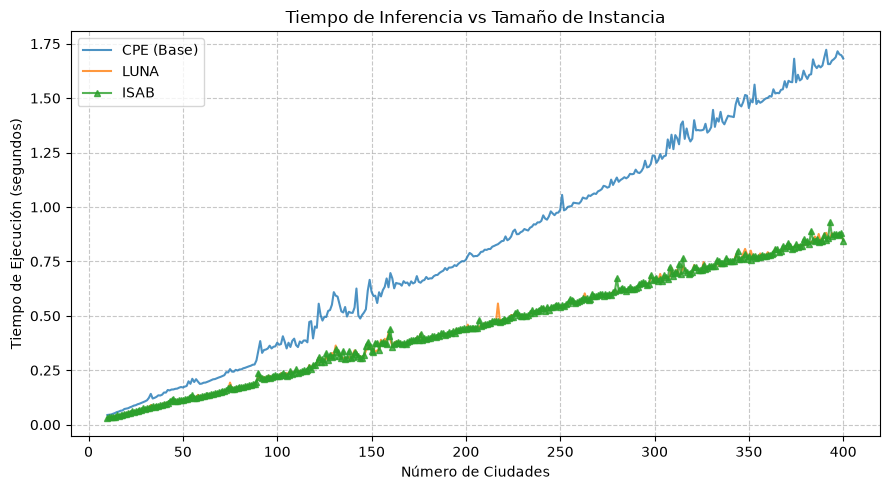

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import time
import torch
import matplotlib.pyplot as plt
from training.sl import load_model
from models.circular_pe import TSPTransformer
from data.adapters.input.default import DefaultInputAdapter
from solvers.model import ModelSolver

# Restringimos explícitamente los hilos de PyTorch
torch.set_num_threads(1)

# Cargamos el modelo Circular PE previamente entrenado
cpe_model = load_model(TSPTransformer, model_name="model_cpe")

# Aseguramos que todos los modelos estén en modo evaluación
cpe_model.eval()
luna_model.eval()
isab_model.eval()

# Inicializamos el adaptador y los solvers
input_adapter = DefaultInputAdapter(max_cities=MAX_CITIES)
cpe_solver = ModelSolver(cpe_model, input_adapter)
luna_solver = ModelSolver(luna_model, input_adapter)
isab_solver = ModelSolver(isab_model, input_adapter)

# Listas para almacenar los tiempos
sizes = range(MIN_CITIES, MAX_CITIES+1)
cpe_times = []
luna_times = []
isab_times = []

# Medimos el tiempo de ejecución para cada instancia sin calcular gradientes
with torch.no_grad():
    for instance in instances:
        # CPE
        start = time.perf_counter()
        cpe_solver.solve_instance(instance)
        cpe_times.append(time.perf_counter() - start)

        # LUNA
        start = time.perf_counter()
        luna_solver.solve_instance(instance)
        luna_times.append(time.perf_counter() - start)

        # ISAB
        start = time.perf_counter()
        isab_solver.solve_instance(instance)
        isab_times.append(time.perf_counter() - start)

# Generamos el gráfico comparativo
plt.figure(figsize=(9, 5))
plt.plot(sizes, cpe_times, label='CPE (Base)', alpha=0.8)
plt.plot(sizes, luna_times, label='LUNA', alpha=0.8)
plt.plot(sizes, isab_times, label='ISAB', alpha=0.8)

plt.title('Tiempo de Inferencia vs Tamaño de Instancia')
plt.xlabel('Número de Ciudades')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()